# Regression with Synthetic Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from keras import layers, Sequential

## 1- Data Preparation

### Create the dataset

In [2]:
# تابع هدف:  y = 0.5·x² - 3·x + sin(2x) + noise
N = 600
x = np.linspace(-5, 8, N)
noise = np.random.normal(0, 0.8, N)
y_true = 0.5 * x**2 - 3 * x + np.sin(2*x)
y = 0.5 * x**2 - 3 * x + np.sin(2*x) + noise

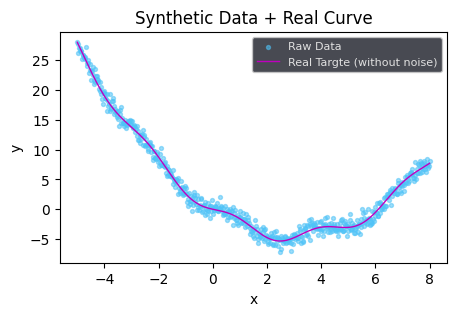

In [3]:
C = {"data":"#4FC3F7", "curve":"m", "text":"#e0e0e0"}
plt.figure(figsize=(5,3))
plt.scatter(x, y, s=8, alpha=0.55, color=C["data"], label="Raw Data")
plt.plot(x, y_true, color=C["curve"], lw=1,
         label="Real Targte (without noise)", zorder=5)
plt.title("Synthetic Data + Real Curve")
plt.xlabel("x");
plt.ylabel("y")
plt.legend(fontsize=8, facecolor="#1a1d27", labelcolor=C["text"])
plt.show()

### Prepare data for training

In [19]:
X = x.reshape(-1, 1)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)
print(f"\n• Train={len(X_train)}  Val={len(X_val)}  Test={len(X_test)}")


• Train=420  Val=90  Test=90


### Data scaling (normalization)

In [40]:
#  Important tip: Only fit the scaler on the train set (not val or test)
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_x.fit_transform(X_train)
X_val_s = scaler_x.transform(X_val)
X_test_s = scaler_x.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

## 2- Model Design

In [33]:
# Method 1
model = Sequential()
model.add(layers.Input(shape=(1,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1))

In [35]:
# Method 2
model = Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

In [36]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

In [39]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [41]:
history = model.fit(X_train_s, y_train_s,
                    epochs=100,
                    batch_size=32,
                    validation_data=(X_val_s, y_val_s))

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9935 - mae: 0.7956 - val_loss: 1.0390 - val_mae: 0.8347
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7009 - mae: 0.6975 - val_loss: 0.7522 - val_mae: 0.7414
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5116 - mae: 0.6168 - val_loss: 0.5159 - val_mae: 0.6314
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3449 - mae: 0.5195 - val_loss: 0.3100 - val_mae: 0.4963
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2082 - mae: 0.3958 - val_loss: 0.1784 - val_mae: 0.3551
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1054 - mae: 0.2702 - val_loss: 0.0830 - val_mae: 0.2362
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0553 - mae: 0.1832 - val_loss: 0.0498 - val_mae: 0.1779
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0445 - mae: 0.1675 - val_loss: 0.0435 - val_mae: 0.1623
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.03

## 4- Evaluation

### Numerical Metrics

In [49]:
val_mse, val_mae = model.evaluate(X_val_s, y_val_s)
print(f'MSE (validation): {val_mse:.4f}')
print(f'MAE (validation): {val_mae:.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0147 - mae: 0.0943
MSE (validation): 0.0147
MAE (validation): 0.0943


In [56]:
y_pred_s = model.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [62]:
mse_test = np.mean((y_test - y_pred)**2)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"   MSE  = {mse_test:.4f}")
print(f"   MAE  = {mae_test:.4f}")
print(f"   R²   = {r2_test:.4f}")

   MSE  = 0.8359
   MAE  = 0.7313
   R²   = 0.9895


### Visualizations

In [76]:
fig = plt.figure(figsize=(18, 14), facecolor="#0f1117")
fig.suptitle("Regression with Synthetic Data",
             fontsize=18, color="white", y=0.98, fontweight="bold")

gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32)

C = {"data":"#4FC3F7","pred":"#FF7043","curve":"#A5D6A7",
     "train":"#FFD54F","val":"#EF9A9A","grid":"#2a2d3a","text":"#e0e0e0"}

def ax_style(ax):
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors=C["text"], labelsize=9)
    for sp in ax.spines.values():
        sp.set_color(C["grid"])
    ax.xaxis.label.set_color(C["text"])
    ax.yaxis.label.set_color(C["text"])
    ax.title.set_color(C["text"])

# ── داده‌ی کامل + منحنی واقعی ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax_style(ax1)
ax1.scatter(x, y, s=8, alpha=0.35, color=C["data"], label="Raw Data")
x_line = np.linspace(-5, 8, 500)
y_true_line = 0.5*x_line**2 - 3*x_line + np.sin(2*x_line)
ax1.plot(x_line, y_true_line, color=C["curve"], lw=2.5,
         label="Real Curve (without noise)", zorder=5)
ax1.set_title("Raw Data + Real Curve")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.legend(fontsize=8, facecolor="#1a1d27", labelcolor=C["text"])

# ── مقایسه پیش‌بینی با واقعیت (Test set) ──────────────
ax2 = fig.add_subplot(gs[0, 1])
ax_style(ax2)
# منحنی پیش‌بینی مدل
x_full_s = scaler_x.transform(x_line.reshape(-1, 1))
y_full_pred_s = model.predict(x_full_s, verbose=0).ravel()
y_full_pred = scaler_y.inverse_transform(
    y_full_pred_s.reshape(-1, 1)).ravel()

ax2.scatter(X_test, y_test, s=15, alpha=0.55,
            color=C["data"], label="Test (Real)", zorder=3)
ax2.plot(x_line, y_true_line, color=C["curve"], lw=2,
         linestyle="--", label="Real Curve", zorder=4)
ax2.plot(x_line, y_full_pred, color=C["pred"], lw=2.5,
         label="Predicted", zorder=5)
ax2.set_title(f"y_true vs y_pred — R²={r2_test:.3f}")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.legend(fontsize=8, facecolor="#1a1d27", labelcolor=C["text"])

# ── منحنی یادگیری ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax_style(ax3)
ep = range(1, len(history.history["loss"]) + 1)
ax3.plot(ep, history.history["loss"],    color=C["train"], lw=2, label="Train Loss")
ax3.plot(ep, history.history["val_loss"],color=C["val"],   lw=2, label="Val Loss",
         linestyle="--")
ax3.set_title("Loss Plot (MSE)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("MSE")
ax3.legend(fontsize=8, facecolor="#1a1d27", labelcolor=C["text"])
ax3.set_yscale("log")

# ── Scatter واقعی vs پیش‌بینی ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax_style(ax4)
ax4.scatter(y_test, y_pred, s=20, alpha=0.6,
            color=C["data"], edgecolors="none")
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
ax4.plot(lims, lims, color=C["pred"], lw=2, linestyle="--",
         label="y=ŷ line")
ax4.set_title(f"y_true vs y_pred |  MAE={mae_test:.3f}")
ax4.set_xlabel("y_true"); ax4.set_ylabel("y_pred")
ax4.legend(fontsize=8, facecolor="#1a1d27", labelcolor=C["text"])

plt.savefig("synthetic_regression_report.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.close()
print("✅ نمودارهای رگرسیون ذخیره شد.")

✅ نمودار رگرسیون ذخیره شد.
